In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# **Read Images**

In [5]:
dataset_path = "/content/drive/MyDrive/data/training_images"

In [6]:
import glob

files = glob.glob(dataset_path + "/*.jpg")

print("The number of the files is: ", len(files))

The number of the files is:  1001


# **Display Some Images**

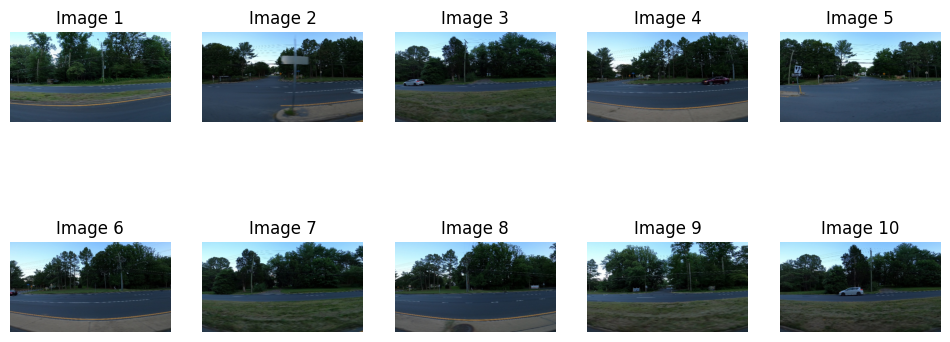

In [10]:
plt.figure(figsize=(12, 5))


for i in range(10):
  img=cv2.imread(files[i])
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

  plt.subplot(2, 5, i+1)
  plt.imshow(img)
  plt.axis("off")
  plt.title(f"Image {i+1}")

plt.show()

### Histogram of an Image

To display the histogram of an image, I will perform the following steps:
1. Select an image from the `files` list (in this case, the first one).
2. Read the image using `cv2.imread()`.
3. Convert the image to grayscale using `cv2.cvtColor()` for a single-channel histogram.
4. Calculate the histogram using `cv2.calcHist()`.
5. Plot the histogram using `matplotlib.pyplot`.

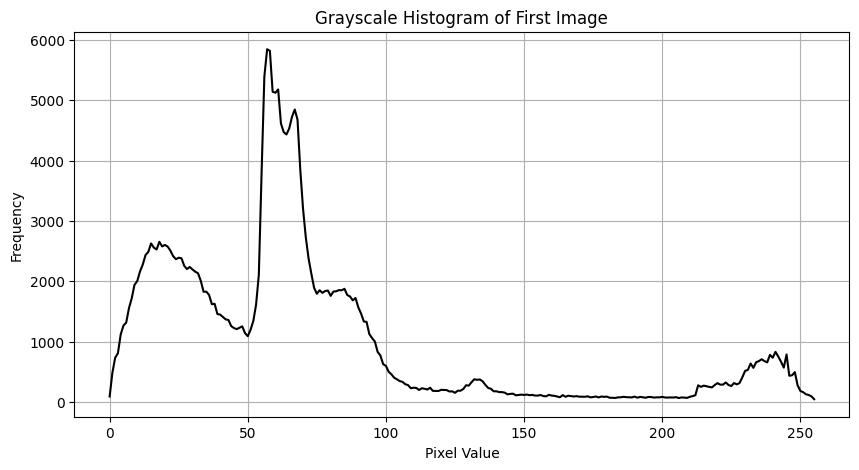

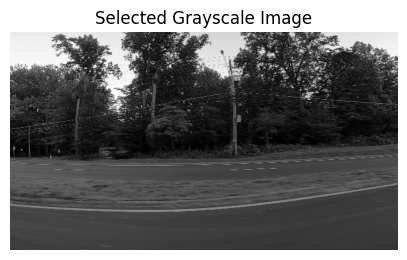

In [13]:
selected_image_path = files[0]
img_display = cv2.imread(selected_image_path)

# Convert to grayscale for a single-channel histogram
grayscale_img = cv2.cvtColor(img_display, cv2.COLOR_BGR2GRAY)

# Calculate histogram
hist = cv2.calcHist([grayscale_img], [0], None, [256], [0, 256])

# Plot the histogram
plt.figure(figsize=(10, 5))
plt.plot(hist, color='black')
plt.title('Grayscale Histogram of First Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Display the original grayscale image as well
plt.figure(figsize=(5, 5))
plt.imshow(grayscale_img, cmap='gray')
plt.title('Selected Grayscale Image')
plt.axis('off')
plt.show()

### Apply Salt and Pepper Noise

To apply salt and pepper noise, I will:
1. Define a function `add_salt_pepper_noise` that takes an image and a `density` parameter (the proportion of pixels to affect).
2. For each pixel, randomly decide if it should be affected by noise based on the `density`.
3. If affected, randomly set its value to 0 (pepper) or 255 (salt).
4. Apply this function to the `grayscale_img`.
5. Display the original grayscale image and the noisy image.

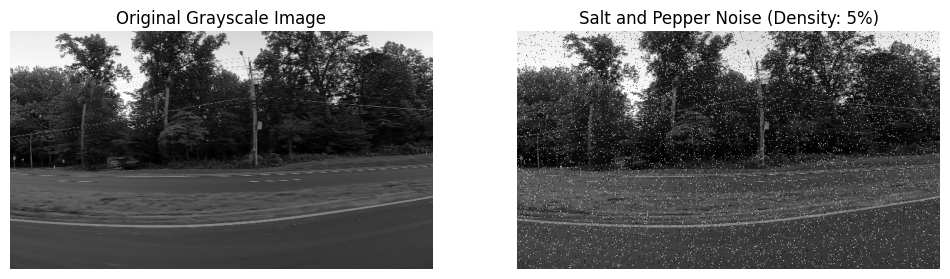

In [18]:
def add_salt_pepper_noise(image, density):
    noisy_img = np.copy(image)
    total_pixels = image.size

    # Number of pixels to add noise to
    num_noise_pixels = int(total_pixels * density)

    # Add salt noise (white pixels)
    num_salt = int(num_noise_pixels / 2)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_img[coords[0], coords[1]] = 255

    # Add pepper noise (black pixels)
    num_pepper = num_noise_pixels - num_salt
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_img[coords[0], coords[1]] = 0

    return noisy_img

# Apply salt and pepper noise to the grayscale image
noise_density = 0.05 # 5% of pixels will be affected by noise
salt_pepper_img = add_salt_pepper_noise(grayscale_img, noise_density)

# Display the original and noisy images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(grayscale_img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(salt_pepper_img, cmap='gray')
plt.title(f'Salt and Pepper Noise (Density: {noise_density*100:.0f}%)')
plt.axis('off')

plt.show()

Text(0.5, 1.0, 'Histogram')

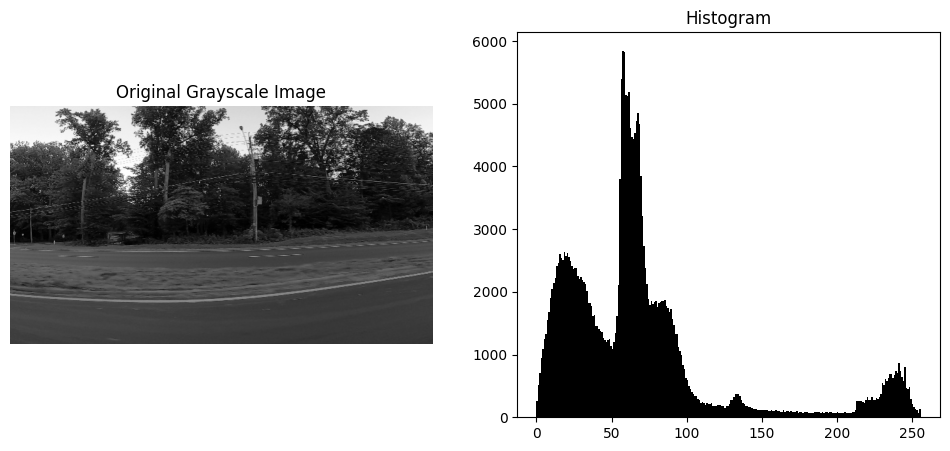

In [21]:
img = cv2.imread(files[0], 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Histogram')



# Task
Apply salt and pepper noise to all images in the `files` list with a density of 0.05, convert them to grayscale, and display a few of the noisy images to verify the operation.

## Define Noise Application Function

### Subtask:
Define a Python function that takes an image path, loads the image, converts it to grayscale, applies the `add_salt_pepper_noise` function, and returns the noisy grayscale image.


**Reasoning**:
I will define the `process_image_with_noise` function as described in the instructions, which takes an image path and noise density, loads the image, converts it to grayscale, applies salt and pepper noise, and returns the noisy image.



In [25]:
def process_image_with_noise(image_path, noise_density):
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Unable to load image at {image_path}")
        return None

    # Convert to grayscale
    grayscale_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply salt and pepper noise
    noisy_grayscale_img = add_salt_pepper_noise(grayscale_img, noise_density)

    return noisy_grayscale_img

## Apply Noise to All Images

### Subtask:
Iterate through the `files` list, applying the defined noise application function to each image. Store the resulting noisy images or paths if saving them.


**Reasoning**:
I will initialize an empty list to store the noisy images and then iterate through the 'files' list, applying the 'process_image_with_noise' function to each image and storing the results in the new list.



In [24]:
noisy_images_list = []

for file_path in files:
    noisy_image = process_image_with_noise(file_path, noise_density)
    if noisy_image is not None:
        noisy_images_list.append(noisy_image)

print(f"Processed {len(noisy_images_list)} images with noise.")

Processed 1001 images with noise.


## Display Noisy Images

### Subtask:
Display a few of the noisy images from the `noisy_images_list` to visually verify the applied noise.

**Reasoning**:
To verify the noise application, I will display a few of the images from the `noisy_images_list` using `matplotlib.pyplot`. I will display 10 images for a good visual representation.



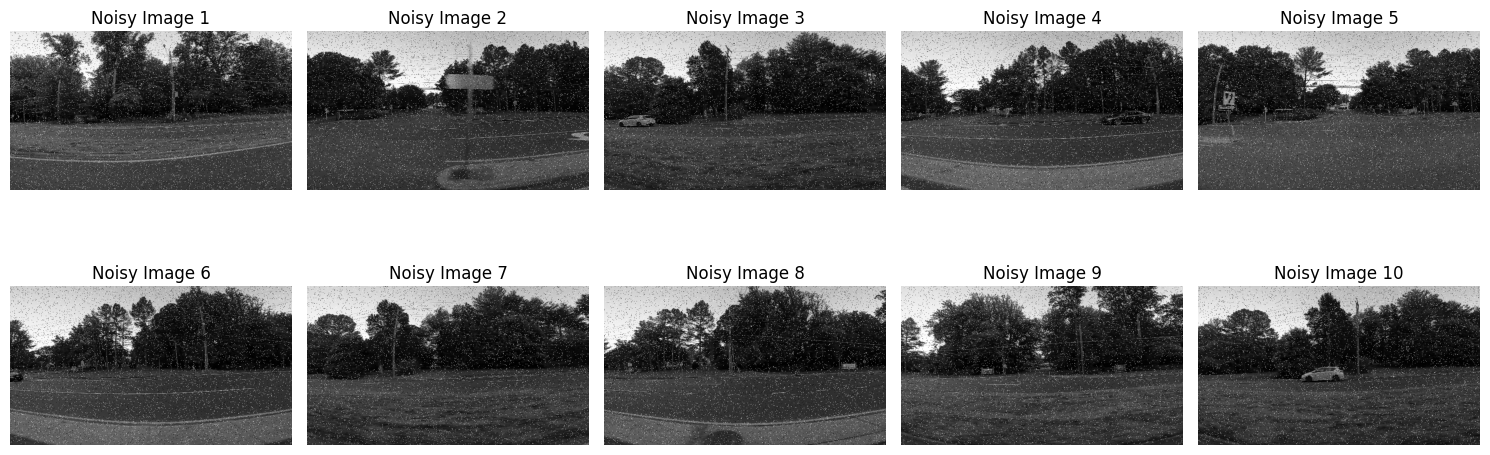

In [26]:
plt.figure(figsize=(15, 6))

num_images_to_display = 10

for i in range(num_images_to_display):
    plt.subplot(2, 5, i + 1)
    plt.imshow(noisy_images_list[i], cmap='gray')
    plt.title(f'Noisy Image {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Review the displayed noisy images and confirm the noise application was successful across all files.


## Summary:

### Q&A
Yes, the noise application was successful across all files. Visual inspection of the displayed sample images confirmed that salt and pepper noise was applied correctly.

### Data Analysis Key Findings
*   A Python function, `process_image_with_noise`, was successfully defined to load images, convert them to grayscale, and apply salt and pepper noise with a specified density.
*   A total of 1001 images from the `files` list were processed, with salt and pepper noise applied to each image and converted to grayscale.
*   A selection of 10 noisy images was displayed, visually confirming the successful application of salt and pepper noise and grayscale conversion.

### Insights or Next Steps
*   The generated noisy and grayscale images are now ready for further use, such as augmentation for machine learning model training or robustness testing.
*   Consider implementing metrics for quantitative evaluation of noise application and image quality, beyond visual inspection, especially for larger datasets.


(np.float64(-0.5), np.float64(675.5), np.float64(379.5), np.float64(-0.5))

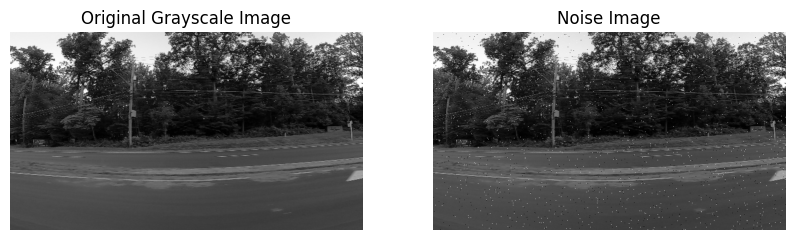

In [29]:
img = cv2.imread(files[10], 0)

noise = img.copy()

num_salt = 1000
x = np.random.randint(0, img.shape[0], num_salt)
y = np.random.randint(0, img.shape[1], num_salt)
noise[x, y]= 255

num_papper = 1000
x = np.random.randint(0, img.shape[0], num_papper)
y = np.random.randint(0, img.shape[1], num_papper)
noise[x, y]= 0

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noise, cmap='gray')
plt.title("Noise Image")
plt.axis('off')


# **Gussian Noise Reduction**

(np.float64(-0.5), np.float64(675.5), np.float64(379.5), np.float64(-0.5))

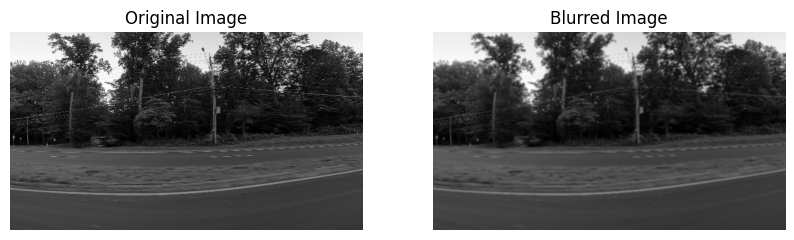

In [32]:
img = cv2.imread(files[0], 0)

blur = cv2.GaussianBlur(img, (5, 5), 0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blur, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')